# Customer Segmentation using Machine Learning
### Online Retail Dataset
**Author:** Passant Shaaban  

#### Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#### Data Loading

In [2]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

#### Data Preprocessing

In [3]:
df.sample(7)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
376747,569533,21844,RED RETROSPOT MUG,6,10/4/2011 15:21,2.95,16374.0,United Kingdom
240906,558118,22134,MINI LADLE LOVE HEART RED,2,6/27/2011 9:11,0.83,NaN,United Kingdom
480210,577286,90214H,"LETTER ""H"" BLING KEY RING",1,11/18/2011 12:39,1.25,14606.0,United Kingdom
480653,577315,47471,RAINBOW PEGS PHOTO CLIP STRING,1,11/18/2011 13:25,0.65,17811.0,United Kingdom
353215,567793,23204,CHARLOTTE BAG APPLES DESIGN,10,9/22/2011 11:40,0.85,12657.0,France
479451,577161,22561,WOODEN SCHOOL COLOURING SET,12,11/18/2011 10:18,1.65,18210.0,United Kingdom
512387,579512,22650,CERAMIC PIRATE CHEST MONEY BANK,1,11/29/2011 16:47,3.29,NaN,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


*Check Duplicates*

In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
df.drop_duplicates(inplace=True)

*Check nulls*

In [8]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [9]:
df = df.dropna(subset=["Description"])

df = df.dropna(subset=["CustomerID"])

*Covert Columns*

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
df["CustomerID"] = df["CustomerID"].astype(int)

*Remove negative quantities which are canceled orders*

In [12]:
df = df[df["Quantity"] > 0]

In [13]:
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
149351,549291,22084,PAPER CHAIN KIT EMPIRE,2,2011-04-07 19:05:00,2.95,16261,United Kingdom
492021,578087,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10,2011-11-22 16:44:00,2.95,15965,United Kingdom
135038,547880,21422,PORCELAIN ROSE SMALL,6,2011-03-27 16:05:00,0.85,15426,United Kingdom
132517,547667,23000,TRAVEL CARD WALLET TRANSPORT,24,2011-03-24 13:25:00,0.42,16700,United Kingdom
355375,567928,22328,ROUND SNACK BOXES SET OF 4 FRUITS,6,2011-09-22 17:31:00,2.95,12380,Belgium


#### Exploratory Data Analysis

*Distribution of quantity*

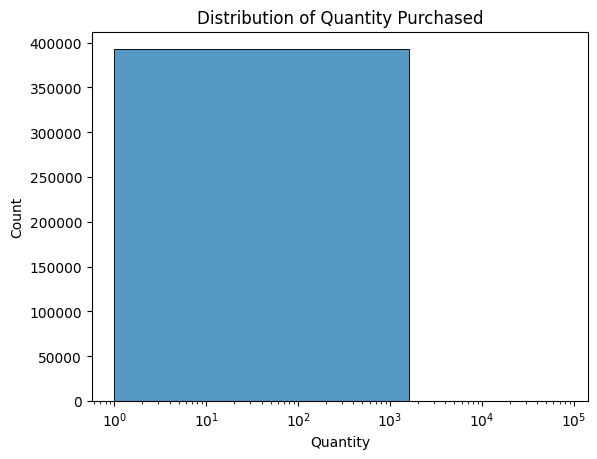

In [14]:
sns.histplot(df["Quantity"], bins=50)
plt.xscale("log")
plt.title("Distribution of Quantity Purchased")
plt.show()

*Distribution of Product Prices*

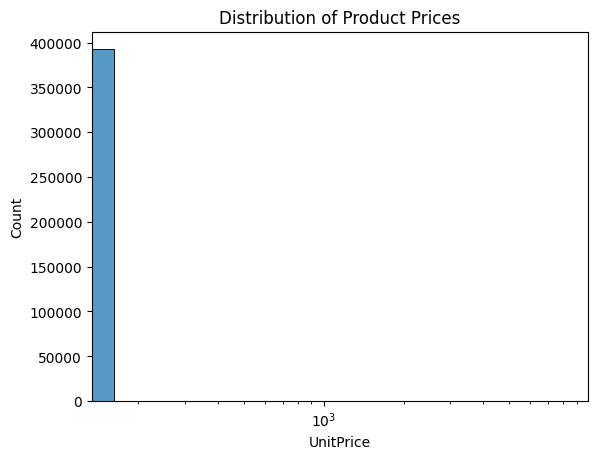

In [15]:
sns.histplot(df["UnitPrice"], bins=50)
plt.xscale("log")
plt.title("Distribution of Product Prices")
plt.show()

*Top Countries by Purchases*

Text(0.5, 1.0, 'Top 10 Countries by Number of Transactions')

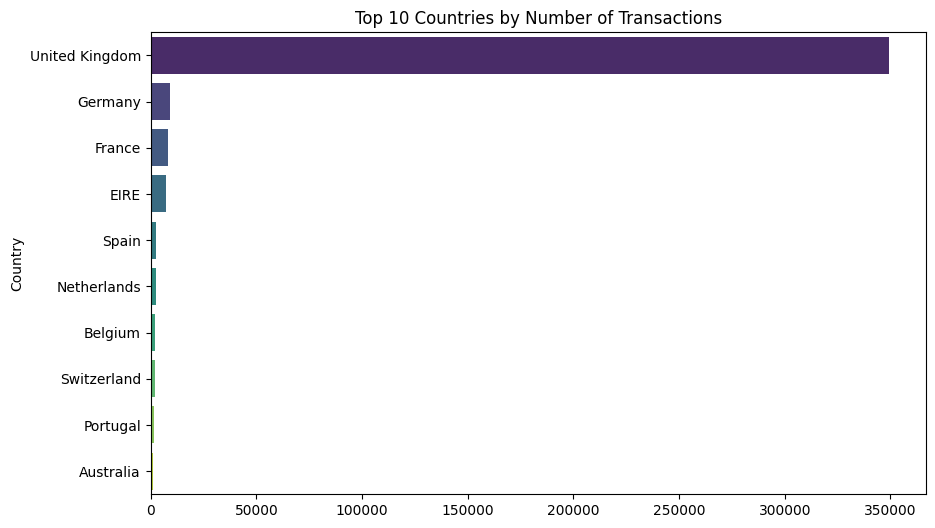

In [16]:
top_countries = df["Country"].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="viridis")
plt.title("Top 10 Countries by Number of Transactions")

*Most sold products*

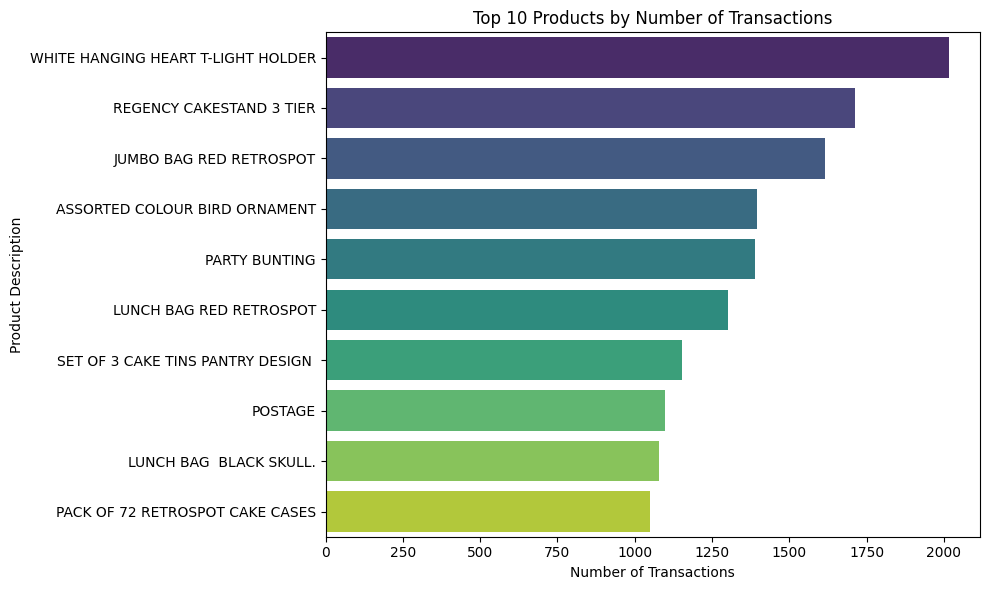

In [17]:
top_products = df['Description'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="viridis")
plt.title("Top 10 Products by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Description")
plt.tight_layout()
plt.show()

*Sales Over Time*

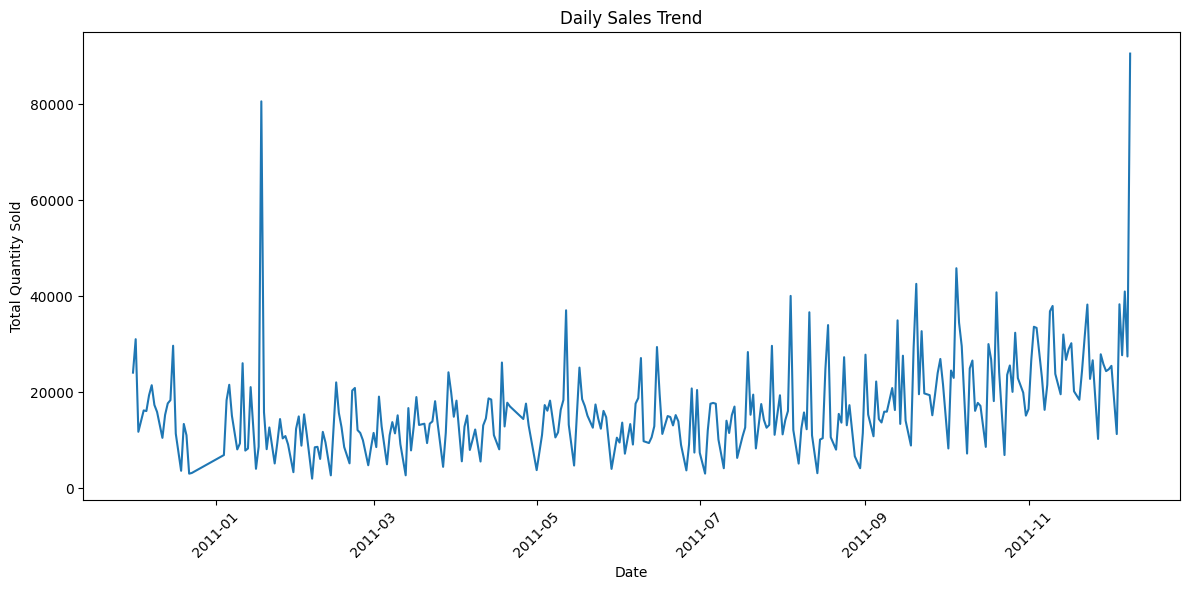

In [18]:
daily_sales = df.groupby(df["InvoiceDate"].dt.date)["Quantity"].sum()
plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Feature Engineering (RFM)

*1. Recency*


*How recently a customer purchased ?*

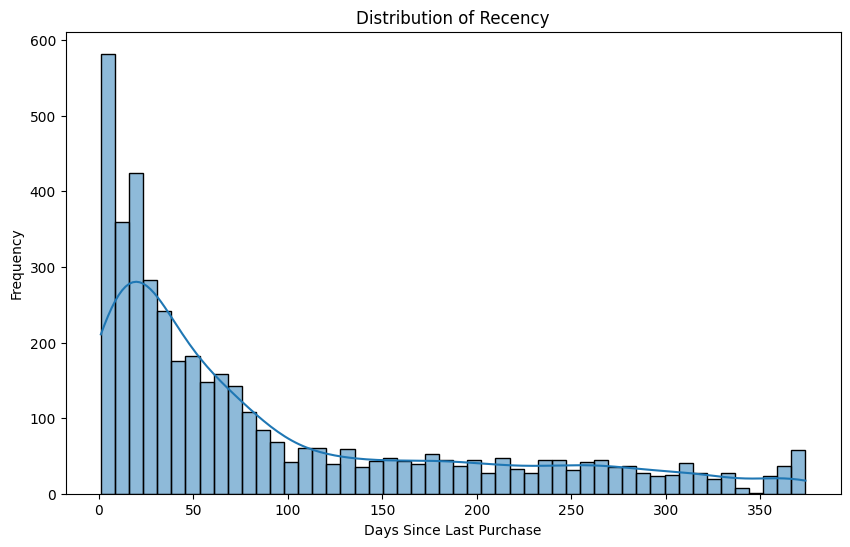

In [19]:
max_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

recency = df.groupby('CustomerID')['InvoiceDate'].max()
recency = (max_date - recency).dt.days
plt.figure(figsize=(10, 6))
sns.histplot(recency, bins=50, kde=True)
plt.title("Distribution of Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Frequency")
plt.show()

*2. Frequency*

*How often they purchase ?*

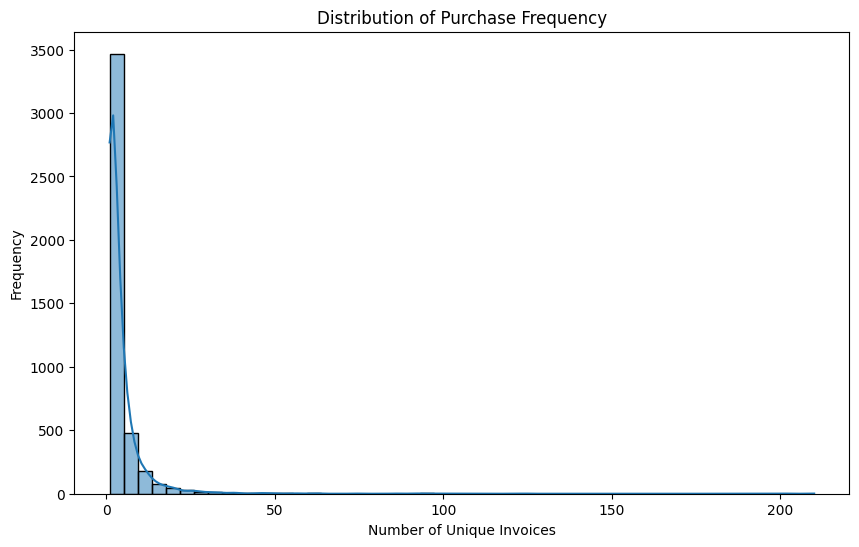

In [20]:
frequency = df.groupby('CustomerID')["InvoiceNo"].nunique()
plt.figure(figsize=(10, 6))
sns.histplot(frequency, bins=50, kde=True)
plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Unique Invoices")
plt.ylabel("Frequency")
plt.show()

*3. Monetary*

*How much money they spend ?*

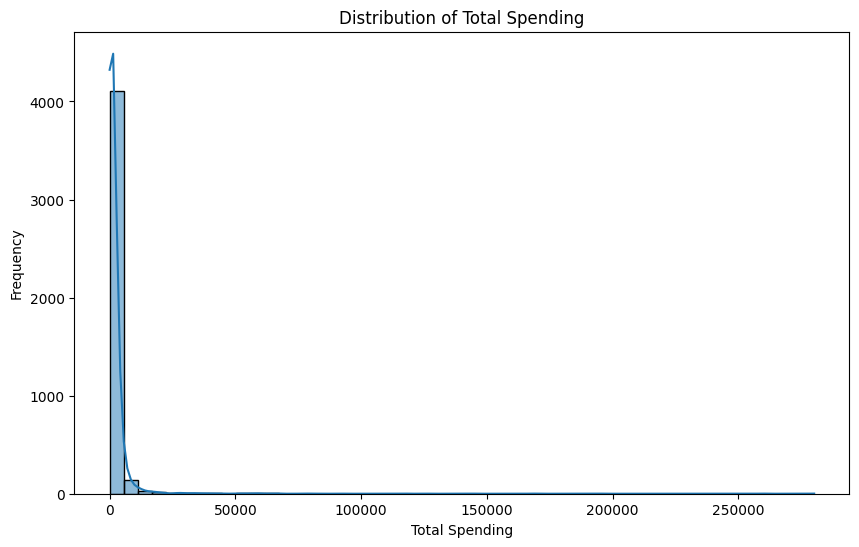

In [21]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
monetary = df.groupby('CustomerID')['TotalPrice'].sum()
plt.figure(figsize=(10, 6))
sns.histplot(monetary, bins=50, kde=True)
plt.title("Distribution of Total Spending") 
plt.xlabel("Total Spending")
plt.ylabel("Frequency")
plt.show()

*Create RFM DataFrame*

In [40]:
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

#### Feature Transformation

*Due to the heavy skewness, I will use log transformation as by this way I will not lose the high customers*

In [41]:
rfm_log = np.log1p(rfm)
rfm_log

,Recency,Frequency,Monetary
CustomerID,,,
12346,5.789960,0.693147,11.253955
12347,1.098612,2.079442,8.368925
12348,4.330733,1.609438,7.494564
12349,2.995732,0.693147,7.472245
12350,5.739793,0.693147,5.815324
...,...,...,...
18280,5.631212,0.693147,5.201806
18281,5.204007,0.693147,4.404522
18282,2.197225,1.098612,5.187665


*Apply Standard Scalar*

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled 

array([[ 1.46223615, -0.95501313,  3.69768662],
       [-2.03861142,  1.07452296,  1.41181999],
       [ 0.37331015,  0.38643726,  0.71904602],
       ...,
       [-1.21878858, -0.36141188, -1.10875557],
       [-1.65741551,  2.1780455 ,  0.8215225 ],
       [-0.03453985,  0.05975492,  0.73649444]], shape=(4339, 3))

*Convert scaled data back to a DataFrame*

In [44]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
rfm_scaled_df

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.462236,-0.955013,3.697687
12347,-2.038611,1.074523,1.411820
12348,0.373310,0.386437,0.719046
12349,-0.622914,-0.955013,0.701362
12350,1.424800,-0.955013,-0.611449
...,...,...,...
18280,1.343773,-0.955013,-1.097551
18281,1.024977,-0.955013,-1.729256
18282,-1.218789,-0.361412,-1.108756


In [60]:
rfm_scaled_df.describe()

,Recency,Frequency,Monetary,Cluster
count,4.339000e+03,4.339000e+03,4.339000e+03,4339.000000
mean,8.187863e-18,1.965087e-17,-2.554613e-16,1.697165
std,1.000115e+00,1.000115e+00,1.000115e+00,1.151509
min,-2.341184e+00,-9.550131e-01,-5.219046e+00,0.000000
25%,-6.611911e-01,-9.550131e-01,-6.803770e-01,1.000000
50%,9.012174e-02,-3.614119e-01,-6.372078e-02,2.000000
75%,8.450137e-01,6.533562e-01,6.562951e-01,3.000000
max,1.564445e+00,5.865344e+00,4.719247e+00,3.000000


#### Clustering

*Using K-means Algorithm*

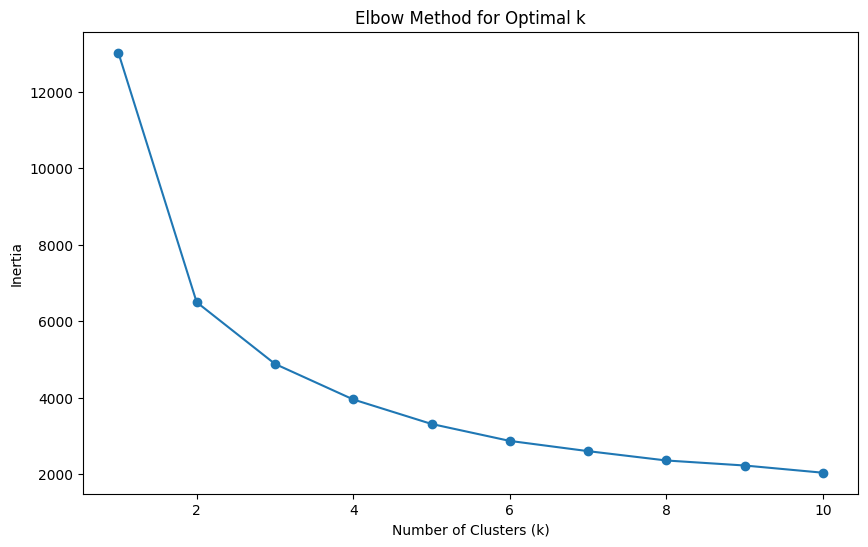

In [45]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

*Choosing k=5 as an optimal number of clusters*

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled_df)

#### Cluster interpretation

In [90]:
rfm['Cluster'] = clusters
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,19.132231,2.066116,529.469551
1,71.130982,4.049538,1772.054041
2,12.108219,13.557534,7942.677890
3,185.662635,1.315086,337.413724


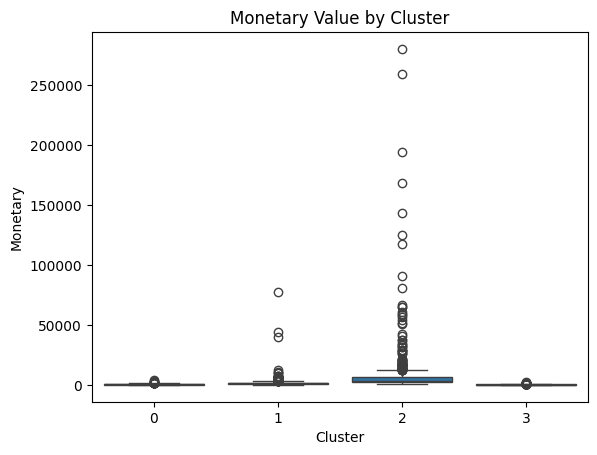

In [92]:
import seaborn as sns

sns.boxplot(x="Cluster", y="Monetary", data=rfm)
plt.title("Monetary Value by Cluster")
plt.show()

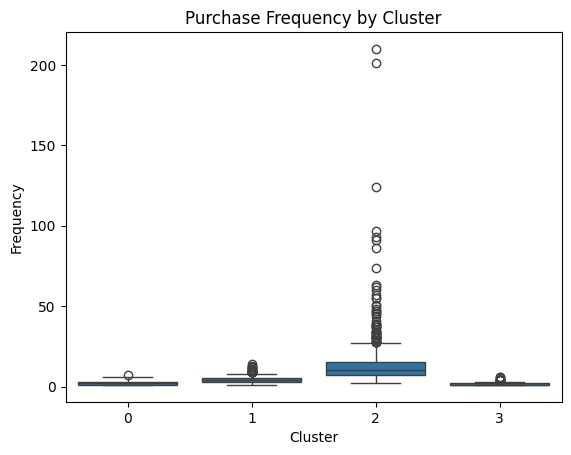

In [93]:
sns.boxplot(x="Cluster", y="Frequency", data=rfm)
plt.title("Purchase Frequency by Cluster")
plt.show()

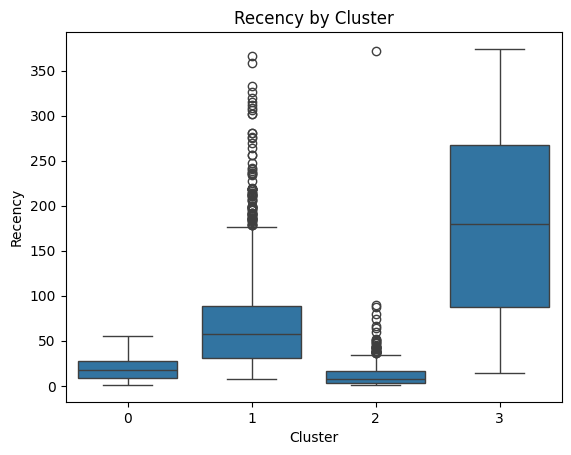

In [94]:
sns.boxplot(x="Cluster", y="Recency", data=rfm)
plt.title("Recency by Cluster")
plt.show()

*Labeling the scaled data*

In [ ]:
rfm_scaled_df['Cluster'] = clusters

*Clusters Visualization*

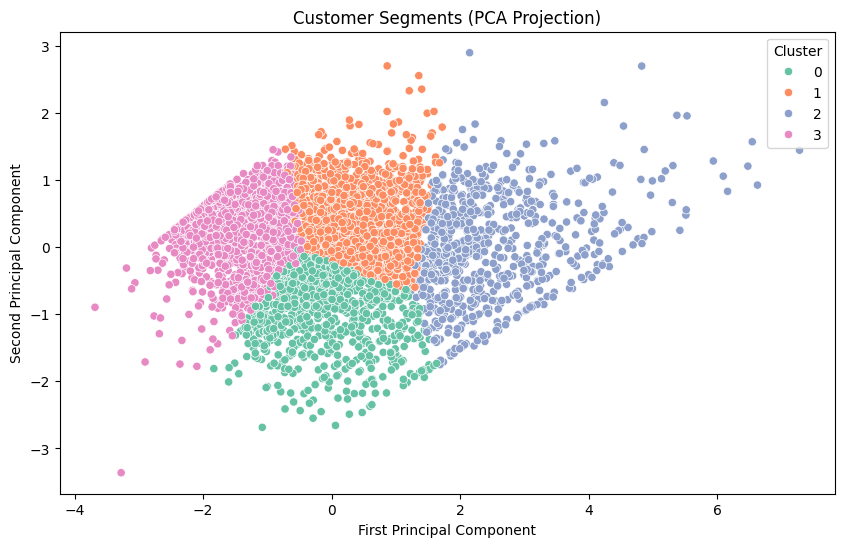

In [51]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rfm_pca[:, 0], y=rfm_pca[:, 1], hue=rfm_scaled_df['Cluster'], palette='Set2')
plt.title("Customer Segments (PCA Projection)")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.show()

#### Classification models

*Define features and target for classification*

In [53]:
X = rfm_scaled_df.drop(['Cluster'], axis=1)
y = rfm_scaled_df['Cluster']

*Split data*

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

*Train KNN*

In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [56]:
knn.score(X_test, y_test)

0.9769585253456221

*Trian SVM*

In [61]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [62]:
svm.score(X_test, y_test)

0.9907834101382489

#### Hyperparameter Tuning

*KNN GridSearch*

In [87]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors' : [2, 3, 5, 7, 10],
    'weights' : ['uniform', 'distance']
}

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid, cv=5)
grid_knn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [2, 3, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [ ]:
grid_knn.best_params_

{'n_neighbors': 7, 'weights': 'distance'}

In [ ]:
grid_knn.best_score_

np.float64(0.9769527087263906)

*SVM GridSearch*

In [80]:
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

In [ ]:
grid_svm = GridSearchCV(SVC(),param_grid_svm,cv=5)

grid_svm.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [82]:
grid_svm.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

In [83]:
grid_svm.best_score_

np.float64(0.9936620156324508)

#### Final Evaluation

In [88]:
knn_y_pred = grid_knn.predict(X_test)
svm_y_pred = grid_svm.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score

print("KNN Accuracy:", accuracy_score(y_test, knn_y_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_y_pred))

KNN Accuracy: 0.9804147465437788
SVM Accuracy: 0.9965437788018433


In [96]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("KNN Classification Report:")
print(classification_report(y_test, knn_y_pred))
print("SVM Classification Report:")
print(classification_report(y_test, svm_y_pred))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       144
           1       0.97      0.98      0.98       247
           2       1.00      0.99      0.99       162
           3       0.98      0.99      0.99       315

    accuracy                           0.98       868
   macro avg       0.98      0.98      0.98       868
weighted avg       0.98      0.98      0.98       868

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       144
           1       0.99      1.00      0.99       247
           2       1.00      1.00      1.00       162
           3       1.00      0.99      1.00       315

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [97]:
print("KNN Confusion Matrix:")
print(confusion_matrix(y_test, knn_y_pred))
print("SVM Confusion Matrix:")
print(confusion_matrix(y_test, svm_y_pred))

KNN Confusion Matrix:
[[135   5   0   4]
 [  2 243   0   2]
 [  2   0 160   0]
 [  0   2   0 313]]
SVM Confusion Matrix:
[[143   1   0   0]
 [  0 247   0   0]
 [  0   0 162   0]
 [  0   2   0 313]]


# Full Project Analytics REPORT

Customer Segmentation and Classification Using Machine Learning

Online Retail Dataset

##### 1. Project Objective

The main objective of this project is to analyze customer purchasing behavior using transactional retail data and segment customers into meaningful groups using machine learning techniques. By identifying distinct customer segments, businesses can better understand customer value, improve marketing strategies, and optimize customer retention efforts.

The project follows a complete machine learning workflow including data preprocessing, feature engineering, clustering, labeling, and classification.

##### 2. Dataset Description

The dataset used in this project is the Online Retail dataset, which contains transactional data from an online retail store.

The dataset includes the following features:

Feature	    Description
InvoiceNo	Unique invoice number for each transaction
StockCode	Unique identifier of each product
Description	Product name
Quantity	Number of units purchased
InvoiceDate	Date and time of the transaction
UnitPrice	Price per product
CustomerID	Unique identifier for each customer
Country	    Customer's country

The dataset contains thousands of transactions and customers, allowing detailed analysis of purchasing behavior.

#### 3. Data Preprocessing

Several preprocessing steps were performed to ensure data quality and reliability.

Handling Missing Values

Rows with missing values in key columns such as CustomerID and Description were removed to maintain data integrity.

Removing Duplicates

Duplicate records were removed to prevent bias in the analysis.

Data Type Conversion

The InvoiceDate column was converted to datetime format to enable time-based feature engineering.

Removing Invalid Transactions

Transactions with negative quantities were removed since they represent product returns rather than purchases.

#### 4. Exploratory Data Analysis

Exploratory analysis was conducted to understand general purchasing patterns and product behavior.

Key observations include:

Product prices and purchase quantities show highly skewed distributions.

A small portion of products generates the majority of sales.

Certain countries contribute significantly more transactions than others.

Transaction activity varies over time, indicating possible seasonal behavior.

These insights highlight the diversity in customer purchasing patterns.

##### 5. Feature Engineering: RFM Analysis

To analyze customer behavior, RFM analysis was implemented. RFM is a widely used customer segmentation technique that summarizes customer activity based on three metrics.

Recency

Measures how recently a customer made their last purchase.

Frequency

Counts how many transactions a customer has made.

Monetary

Measures the total amount of money spent by a customer.

These metrics capture the value and engagement level of each customer.

##### 6. Feature Transformation

The RFM variables were highly skewed, particularly the Monetary and Frequency features.

To address this issue:

Log Transformation

A log transformation was applied to reduce skewness and stabilize variance.

Standard Scaling

StandardScaler was applied to normalize the feature ranges before clustering.

This transformation improves clustering performance and ensures that all features contribute equally.

##### 7. Customer Segmentation Using K-Means Clustering

K-Means clustering was applied to segment customers based on their RFM characteristics.

Determining the Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of clusters. The analysis indicated that four clusters provided a suitable balance between model simplicity and segmentation detail.

Clustering Results

The average RFM values for each cluster are shown below:

| Cluster | Recency | Frequency | Monetary |
|--------|--------|--------|--------|
| 0 | 19.13 | 2.07 | 529.47 |
| 1 | 71.13 | 4.05 | 1772.05 |
| 2 | 12.11 | 13.56 | 7942.68 |
| 3 | 185.66 | 1.32 | 337.41 |

##### 8. Cluster Interpretation

Based on the RFM values, each cluster represents a distinct customer segment.

Cluster 2 – High-Value / VIP Customers

This cluster has the highest frequency and monetary value with very recent purchases.

Characteristics:

Very recent purchases (low recency)

Very frequent transactions

Highest spending levels

These customers represent the most valuable segment and contribute significantly to total revenue.

Cluster 1 – Loyal Regular Customers

Customers in this cluster purchase regularly and have relatively high spending levels.

Characteristics:

Moderate recency

Moderate frequency

High spending

These customers represent loyal and stable customers who regularly contribute to revenue.

Cluster 0 – Occasional Customers

Customers in this cluster purchase infrequently but have relatively recent transactions.

Characteristics:

Recent purchases

Low purchase frequency

Moderate spending

These customers may represent new or occasional buyers who could potentially be converted into loyal customers.

Cluster 3 – Inactive or Lost Customers

This cluster contains customers who have not purchased for a long time.

Characteristics:

Very high recency (long time since last purchase)

Very low purchase frequency

Low spending

These customers represent inactive or churned customers who may require re-engagement strategies.

##### 9. Cluster Labeling

The cluster assignments produced by K-Means were used as labels to create a supervised learning dataset. This allows classification models to learn the structure of customer segments and predict the segment of new customers.

##### 10. Classification Models

Two machine learning classification models were implemented to predict customer segments.

K-Nearest Neighbors (KNN)

KNN classifies customers based on similarity with nearby customers in feature space.

Support Vector Machine (SVM)

SVM constructs optimal decision boundaries to separate customer segments effectively.

##### 11. Hyperparameter Optimization

GridSearchCV with cross-validation was used to identify the optimal parameters for both models.

For KNN:

Number of neighbors

Weighting method

For SVM:

Kernel type

Regularization parameter

Gamma value

This step ensures improved model performance and robustness.

##### 12. Model Evaluation

The trained models were evaluated using classification metrics including accuracy and confusion matrices.

Both models demonstrated strong performance in predicting customer segments, indicating that the clustering structure was well captured by the classification algorithms.

##### 13. Business Insights

The segmentation results provide valuable insights into customer behavior:

A small group of VIP customers contributes the highest revenue.

Loyal regular customers represent a stable revenue source.

Occasional customers present an opportunity for marketing campaigns to increase engagement.

Inactive customers may require targeted reactivation strategies.

These insights can help businesses design personalized marketing strategies and improve customer retention.

##### 14. Conclusion

This project successfully demonstrated a full machine learning pipeline for customer segmentation and classification.

Key accomplishments include:

Cleaning and preparing transactional retail data

Conducting exploratory data analysis

Engineering RFM features to represent customer behavior

Applying K-Means clustering to segment customers

Interpreting clusters to identify meaningful customer groups

Training classification models to predict customer segments

Optimizing models using cross-validation

The resulting segmentation provides valuable insights that can support data-driven decision making in customer relationship management and marketing strategy.